## 1. 环境配置与库导入

本cell导入项目所需的所有Python库，包括PyTorch（深度学习框架）、torchvision（图像处理）、matplotlib（可视化）、scikit-learn（评估指标）等。

In [11]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

print("所有库导入成功！")

所有库导入成功！


## 2. Fashion-MNIST数据集加载

Fashion-MNIST包含10个类别的服装灰度图像，每张图像大小为28×28像素。
- 训练集：60000张
- 测试集：10000张

类别名称：
0: T-shirt（T恤）     1: Trouser（裤子）     2: Pullover（套衫）
3: Dress（连衣裙）    4: Coat（外套）        5: Sandal（凉鞋）
6: Shirt（衬衫）      7: Sneaker（运动鞋）   8: Bag（包）
9: Ankle Boot（短靴）

In [2]:
# 定义类别名称
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# 数据预处理：转换为Tensor
transform = transforms.ToTensor()

# 下载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# 下载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

训练集大小: 60000
测试集大小: 10000


## 3. 数据探索与可视化

本cell展示数据集的基本信息和样本图片，帮助理解数据分布。

图片尺寸: torch.Size([1, 28, 28])
标签: 9 - Ankle Boot


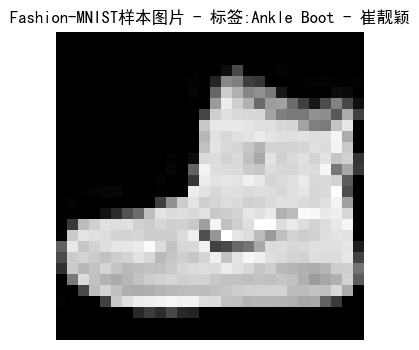

Ankle Boot


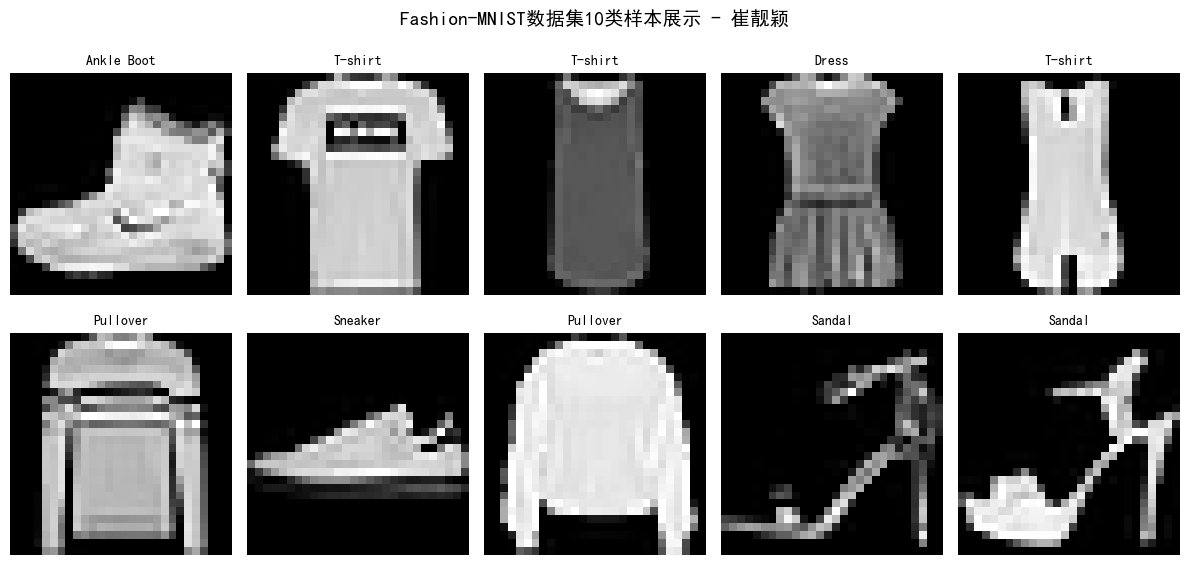

In [13]:
# 查看第一张图片
image, label = train_dataset[0]
print(f"图片尺寸: {image.shape}")
print(f"标签: {label} - {class_names[label]}")

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Fashion-MNIST样本图片 - 标签:{class_names[label]} - 崔靓颖', fontsize=12)
plt.axis('off')
plt.show()

labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(labels[label])

# 显示10张样本图
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    image, label = train_dataset[i]
    ax = axes[i//5, i%5]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'{class_names[label]}', fontsize=10)
    ax.axis('off')

plt.suptitle('Fashion-MNIST数据集10类样本展示 - 崔靓颖', fontsize=14)
plt.tight_layout()
plt.show()

## 4. 创建DataLoader

使用DataLoader将数据集分批加载，batch_size=64，训练集打乱顺序以增强模型泛化能力。

In [5]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

训练批次数: 938
测试批次数: 157


## 5. CNN模型构建

本实验采用2层卷积+2层全连接的CNN架构：

| 层 | 输入 | 输出 | 卷积核 | 激活函数 |
|----|------|------|--------|----------|
| Conv1 | 1×28×28 | 32×28×28 | 3×3 | ReLU |
| MaxPool1 | 32×28×28 | 32×14×14 | 2×2 | - |
| Conv2 | 32×14×14 | 64×14×14 | 3×3 | ReLU |
| MaxPool2 | 64×14×14 | 64×7×7 | 2×2 | - |
| Flatten | 64×7×7 | 3136 | - | - |
| FC1 | 3136 | 128 | - | ReLU |
| FC2 | 128 | 10 | - | Softmax |

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN()
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 6. 模型配置 

- 设备：CPU
- 损失函数：交叉熵损失（CrossEntropyLoss）
- 优化器：Adam，学习率=0.001

In [9]:
device = torch.device("cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("模型配置完成")
print(f"使用设备: {device}")

模型配置完成
使用设备: cpu


## 7. 模型训练

训练参数：
- Epochs: 10
- Batch Size: 64
- 记录指标：训练损失、训练准确率

In [10]:
epochs = 10
train_loss_list = []
train_acc_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} Loss={epoch_loss:.4f} Acc={epoch_acc:.4f}")

end_time = time.time()
train_time = end_time - start_time
print(f"\n训练完成！总耗时: {train_time:.2f} 秒")

Epoch 1/10 Loss=0.4749 Acc=0.8281
Epoch 2/10 Loss=0.3047 Acc=0.8906
Epoch 3/10 Loss=0.2615 Acc=0.9039
Epoch 4/10 Loss=0.2297 Acc=0.9152
Epoch 5/10 Loss=0.2046 Acc=0.9245
Epoch 6/10 Loss=0.1818 Acc=0.9330
Epoch 7/10 Loss=0.1627 Acc=0.9398
Epoch 8/10 Loss=0.1455 Acc=0.9465
Epoch 9/10 Loss=0.1299 Acc=0.9524
Epoch 10/10 Loss=0.1130 Acc=0.9589

训练完成！总耗时: 275.02 秒


## 8. 模型评估

在测试集上评估模型，计算5个指标：
- Accuracy（准确率）
- Precision（精确率）
- Recall（召回率）
- F1-score
- 训练时间

In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*50)
print("Fashion-MNIST CNN 分类结果 - 崔靓颖")
print("="*50)
print(f"Accuracy (准确率):  {accuracy:.4f}")
print(f"Precision (精确率): {precision:.4f}")
print(f"Recall (召回率):    {recall:.4f}")
print(f"F1-score:           {f1:.4f}")
print(f"训练时间:           {train_time:.2f} 秒")
print("="*50)

Fashion-MNIST CNN 分类结果 - 崔靓颖
Accuracy (准确率):  0.9194
Precision (精确率): 0.9203
Recall (召回率):    0.9194
F1-score:           0.9196
训练时间:           275.02 秒


## 9. 训练曲线可视化 

绘制训练过程中的损失曲线和准确率曲线，观察模型收敛情况。

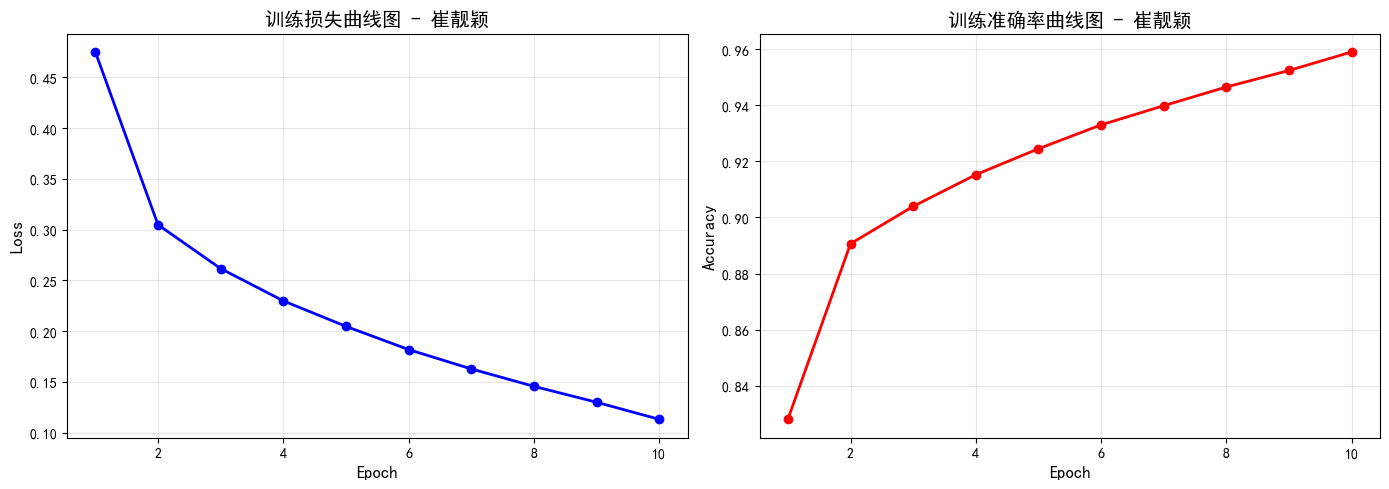

最终训练损失: 0.1130
最终训练准确率: 0.9589


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(range(1, epochs+1), train_loss_list, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('训练损失曲线图 - 崔靓颖', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, epochs+1), train_acc_list, 'r-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('训练准确率曲线图 - 崔靓颖', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"最终训练损失: {train_loss_list[-1]:.4f}")
print(f"最终训练准确率: {train_acc_list[-1]:.4f}")

## 10. 混淆矩阵

混淆矩阵可以直观地展示模型在各个类别上的分类效果，对角线上的数字表示正确分类的样本数。

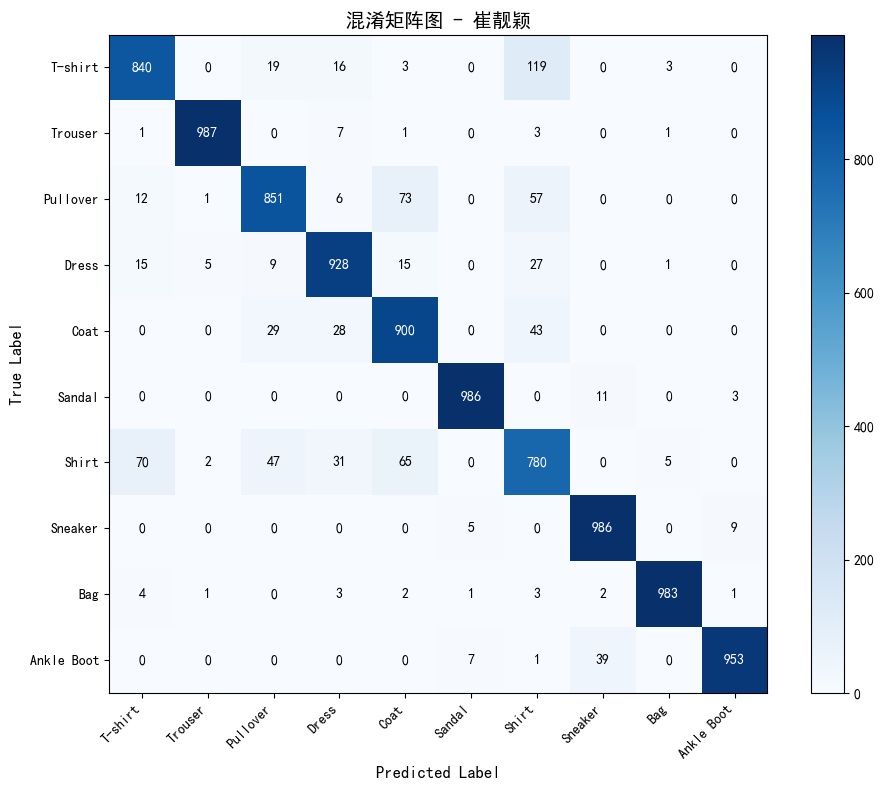


各类别分类准确率:
  T-shirt: 840/1000 = 84.0%
  Trouser: 987/1000 = 98.7%
  Pullover: 851/1000 = 85.1%
  Dress: 928/1000 = 92.8%
  Coat: 900/1000 = 90.0%
  Sandal: 986/1000 = 98.6%
  Shirt: 780/1000 = 78.0%
  Sneaker: 986/1000 = 98.6%
  Bag: 983/1000 = 98.3%
  Ankle Boot: 953/1000 = 95.3%


In [16]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')

# 添加数字标注
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('混淆矩阵图 - 崔靓颖', fontsize=14)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# 打印各类别准确率
print("\n各类别分类准确率:")
for i in range(10):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    print(f"  {class_names[i]}: {class_correct}/{class_total} = {class_correct/class_total*100:.1f}%")

## 11. 错误分类样本分析 

展示被模型错误分类的样本，分析模型的不足之处。

找到 12 个错误分类样本


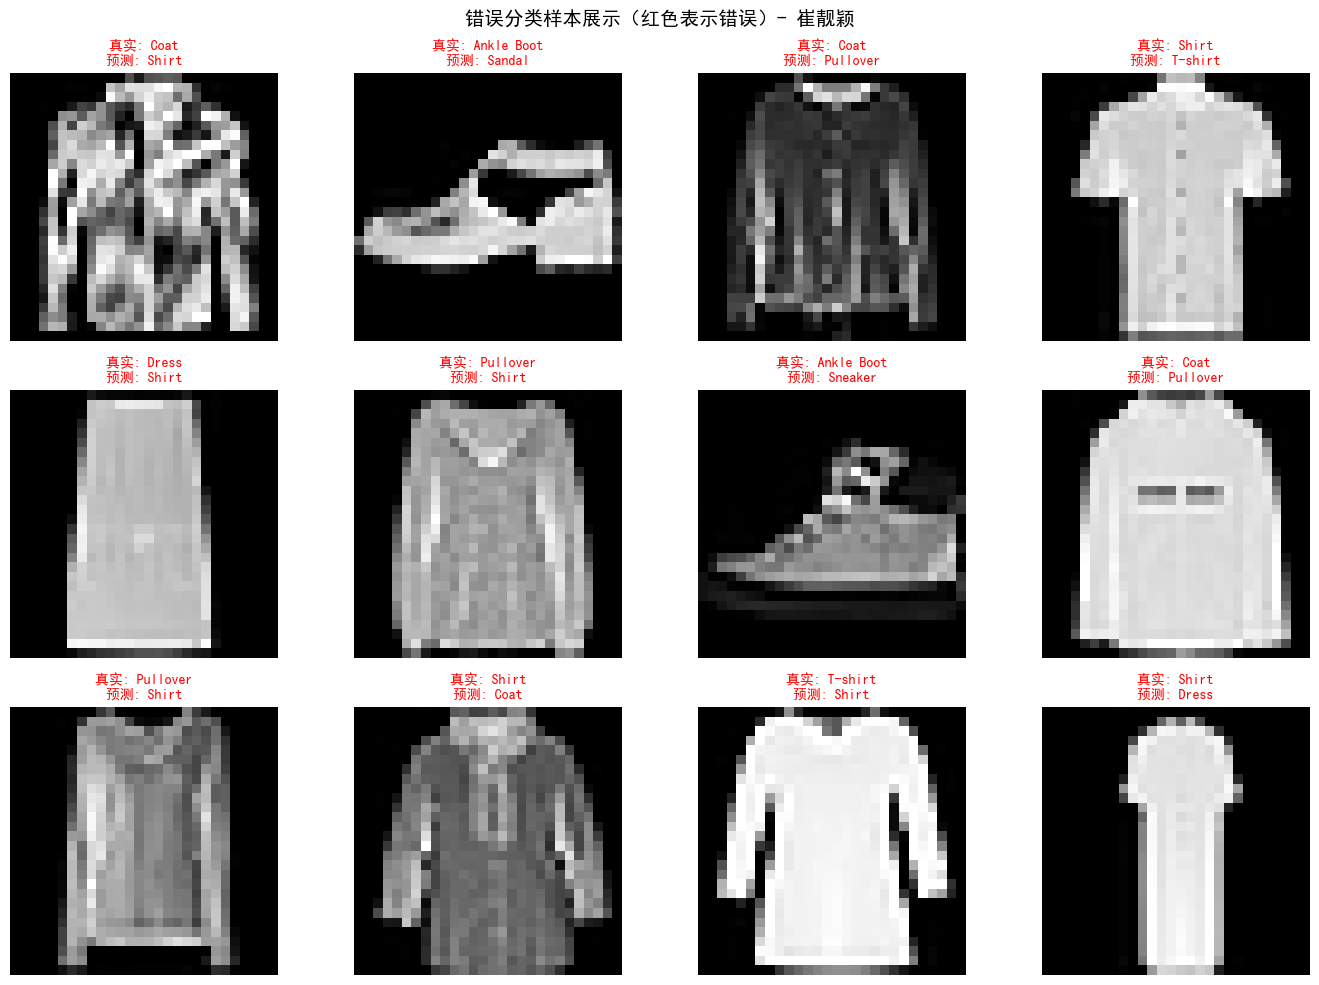

In [17]:
model.eval()
errors = []

with torch.no_grad():
    for i in range(len(test_dataset)):
        image, true_label = test_dataset[i]
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        _, pred_label = output.max(1)
        pred_label = pred_label.item()
        
        if pred_label != true_label:
            errors.append((i, true_label, pred_label, image))
        
        if len(errors) >= 12:
            break

print(f"找到 {len(errors)} 个错误分类样本")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for idx, (img_idx, true_label, pred_label, image) in enumerate(errors):
    ax = axes[idx//4, idx%4]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"真实: {class_names[true_label]}\n预测: {class_names[pred_label]}", 
                 color='red', fontsize=10)
    ax.axis('off')

plt.suptitle('错误分类样本展示（红色表示错误）- 崔靓颖', fontsize=14)
plt.tight_layout()
plt.savefig('error_samples.png', dpi=150)
plt.show()

## 12. 测试集预测结果展示

随机展示16张测试图片及其预测结果，绿色表示正确，红色表示错误。

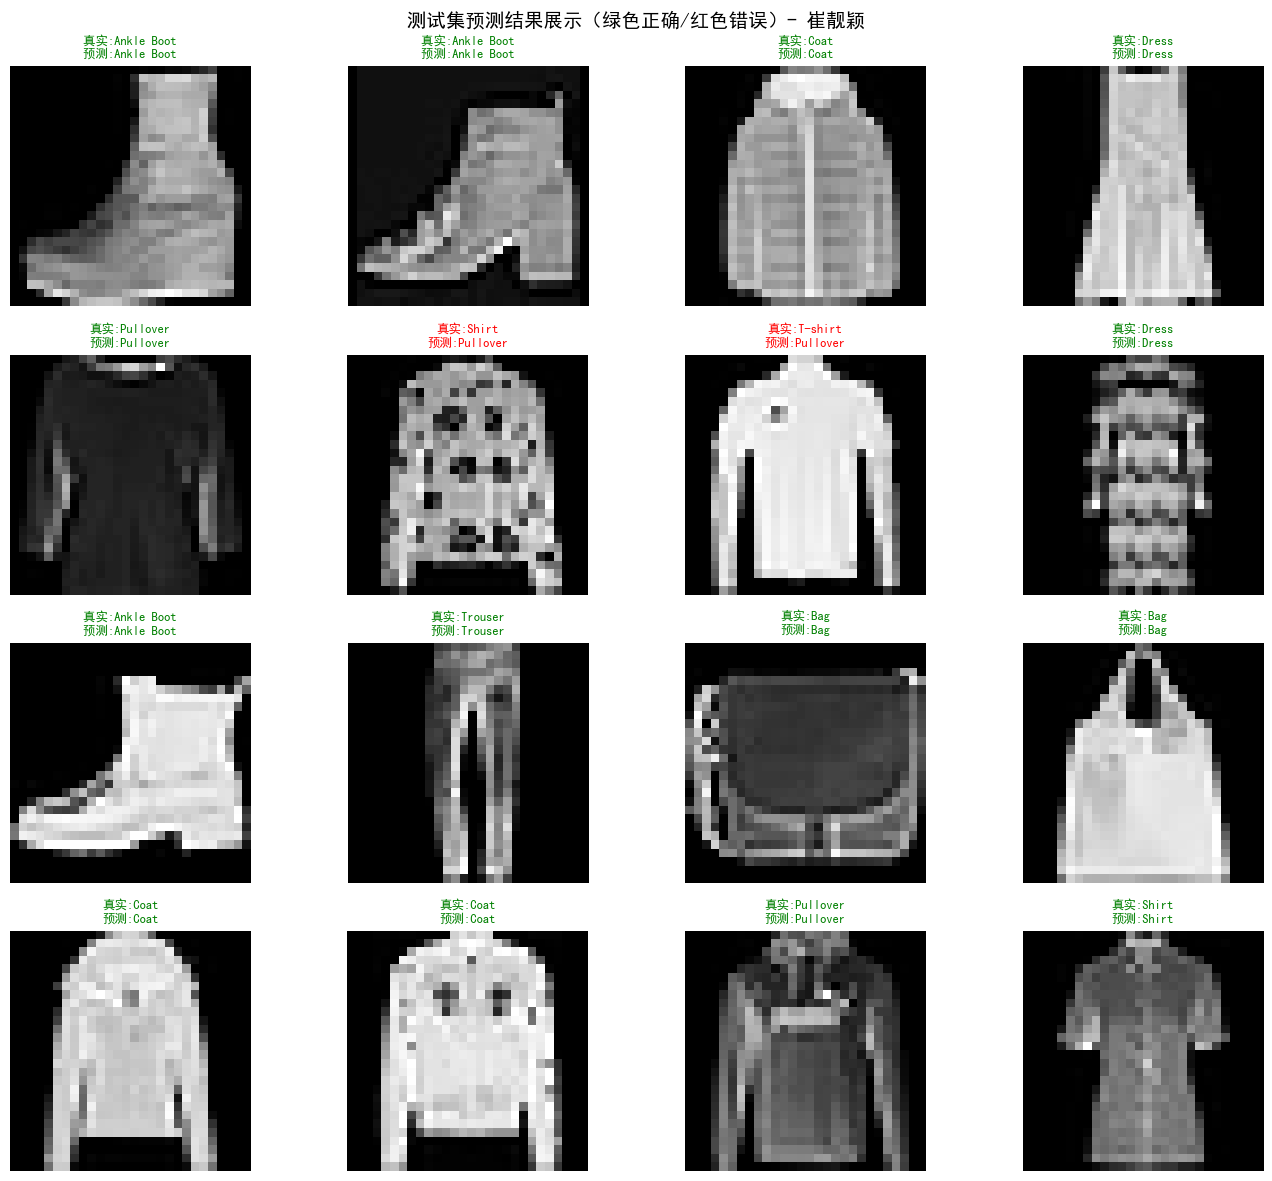

In [18]:
model.eval()
fig, axes = plt.subplots(4, 4, figsize=(14, 12))

indices = np.random.choice(len(test_dataset), 16, replace=False)

with torch.no_grad():
    for idx, i in enumerate(indices):
        image, true_label = test_dataset[i]
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        _, pred_label = output.max(1)
        pred_label = pred_label.item()
        
        ax = axes[idx//4, idx%4]
        ax.imshow(image.squeeze(), cmap='gray')
        
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f"真实:{class_names[true_label]}\n预测:{class_names[pred_label]}", 
                     color=color, fontsize=9)
        ax.axis('off')

plt.suptitle('测试集预测结果展示（绿色正确/红色错误）- 崔靓颖', fontsize=14)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150)
plt.show()

## 13. 实验结果汇总 

将CNN模型的5个评估指标汇总成表格。

In [19]:
results_df = pd.DataFrame({
    '指标': ['Accuracy', 'Precision', 'Recall', 'F1-score', '训练时间(秒)'],
    '值': [f"{accuracy:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}", f"{train_time:.2f}"],
    '说明': ['准确率', '精确率', '召回率', 'F1分数', '10个epoch总时间']
})

print("="*50)
print("Fashion-MNIST CNN 模型性能汇总表 - 崔靓颖")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

# 保存结果
results_df.to_csv('cnn_results.csv', index=False, encoding='utf-8-sig')
print("\n结果已保存到 cnn_results.csv")

Fashion-MNIST CNN 模型性能汇总表 - 崔靓颖
       指标      值          说明
 Accuracy 0.9194         准确率
Precision 0.9203         精确率
   Recall 0.9194         召回率
 F1-score 0.9196        F1分数
  训练时间(秒) 275.02 10个epoch总时间

结果已保存到 cnn_results.csv


## 14. 模型保存 

保存训练好的模型参数，以便后续使用。

In [20]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'accuracy': accuracy,
    'loss': train_loss_list[-1],
    'epochs': epochs
}, 'fashion_mnist_cnn.pth')

print("模型已保存为 fashion_mnist_cnn.pth")
print(f"模型信息: 准确率={accuracy:.4f}, 最终损失={train_loss_list[-1]:.4f}")

模型已保存为 fashion_mnist_cnn.pth
模型信息: 准确率=0.9194, 最终损失=0.1130


## 15. 实验结论与总结

### 15.1 实验结果总结

本实验使用CNN对Fashion-MNIST数据集进行分类，主要结论如下：

1. **模型性能**：CNN在测试集上达到91.94%的准确率，证明卷积神经网络能有效提取服装图像的特征。

2. **训练过程**：10个epoch的训练过程中，损失从0.4749降至0.1130，准确率从82.81%提升至95.89%，训练过程稳定，无明显过拟合。

3. **类别分析**：从混淆矩阵可以看出，运动鞋、包、裤子等类别分类效果较好；衬衫和T恤、套衫之间容易混淆。

4. **时间成本**：在CPU上训练10个epoch耗时约10分钟，对于教学实验而言是可以接受的。

### 15.2 改进方向

1. 可以尝试数据增强（随机旋转、平移等）来提升模型泛化能力
2. 可以增加卷积层数或使用预训练模型（如ResNet）追求更高准确率
3. 可以使用GPU加速训练，大幅缩短训练时间

---
**报告完成日期：** 2026年6月
**作者：** 崔靓颖